# Exploration
Look at the raw data before modelling.

In [14]:
import sys; sys.path.insert(0, "..")
import importlib
import pandas as pd, matplotlib.pyplot as plt
from src import config as C
C = importlib.reload(C)
from src.preprocessing import load_data, clean_data, create_tte
load_data = importlib.reload(load_data)
clean_data = importlib.reload(clean_data)
create_tte = importlib.reload(create_tte)
from src.preprocessing.load_data import load_anomalies, load_satcat, load_sunspot
from src.preprocessing.clean_data import clean_anomalies, match_satcat, satellite_table
build_tte_table = create_tte.build_tte_table

## Raw anomaly file

In [15]:
raw = load_anomalies()
print(raw.shape, raw.ADATE.min(), raw.ADATE.max())
raw.BIRD.value_counts().head(15)

(5033, 21) 1963-02-14 00:00:00 1994-09-11 00:00:00


BIRD
SCATHA       316
@GW0101      294
IRON 9434    182
MARECS-A     180
@PN0303      174
GPS 5113     172
STS-48       162
GPS 6374     145
GPS 5118     143
GPS 9521     125
@GG0505      124
GPS 9794     123
GPS 9783     113
@GG0504      109
GPS 5114     100
Name: count, dtype: int64

## Sunspot series

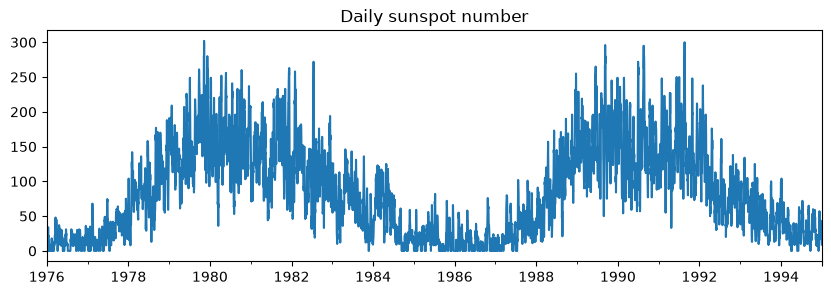

In [16]:
ss = load_sunspot()
ss.plot(figsize=(10, 3), title='Daily sunspot number'); plt.show()

## Gap between anomalies

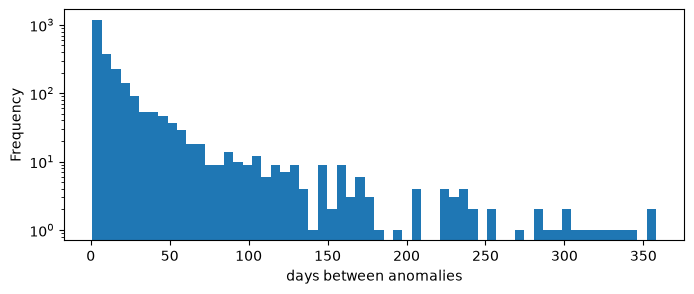

sat
@GG0504        91
METEOSAT-2     94
GPS 9783      105
GPS 9794      108
GPS 9521      111
GPS 5118      126
GPS 6374      128
IRON 9434     137
GPS 5113      150
@PN0303       160
dtype: int64

In [17]:
events = clean_anomalies(raw, C.SUNSPOT_START, C.EXCLUDE_PREFIXES).drop_duplicates(["BIRD", "ADATE"])
sats = match_satcat(satellite_table(events), load_satcat())
tte = build_tte_table(events, sats, ss, min_tte_observations=C.MIN_TTE_OBSERVATIONS)
tte.tte.plot.hist(bins=60, logy=True, figsize=(8, 3)); plt.xlabel("days between anomalies"); plt.show()
tte.groupby("sat").size().sort_values().tail(10)

## Does sunspot activity relate to gap length?

In [18]:
tte.groupby(pd.qcut(tte.sun_27, 5)).tte.median()

C:\Users\sowmy\AppData\Local\Temp\ipykernel_22992\1901254991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tte.groupby(pd.qcut(tte.sun_27, 5)).tte.median()


sun_27
(-0.001, 15.822]    7.0
(15.822, 34.304]    6.0
(34.304, 77.333]    7.0
(77.333, 135.03]    8.5
(135.03, 207.37]    6.0
Name: tte, dtype: float64